In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\LOQ\Desktop\Machine Learning\Linear Regression\data\raw\House Price Prediction Dataset.csv')
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [3]:
data = df.copy()

In [4]:
data.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1995,1996,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,1997,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1998,1062,5,1,2,1903,Rural,Poor,No,476925
1998,1999,4062,3,1,2,1936,Urban,Excellent,Yes,161119
1999,2000,2989,5,1,3,1903,Suburban,Fair,No,482525


In [5]:
data.shape

(2000, 10)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 184.3 KB


In [7]:
data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [8]:
data['Id'].duplicated().sum()

np.int64(0)

<Axes: title={'center': '10 Most prefer area to build house'}, xlabel='Area', ylabel='Counts'>

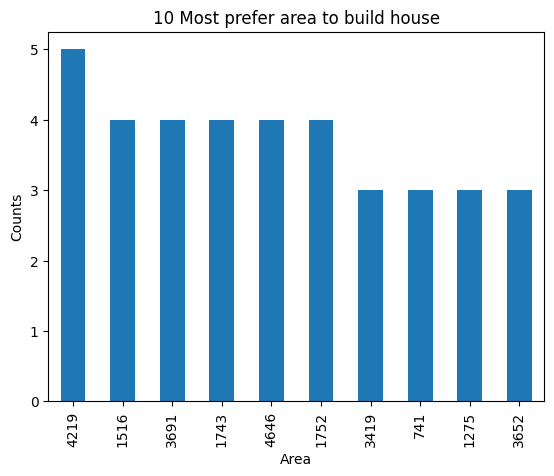

In [9]:
data['Area'].value_counts().head(10).plot(kind='bar',title='10 Most prefer area to build house',ylabel='Counts')

<Axes: title={'center': 'Prefered Bedrooms by People in House'}, xlabel='Bedrooms', ylabel='Total Counts'>

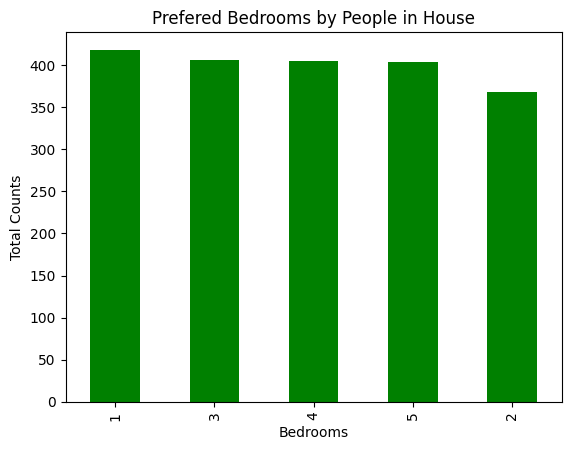

In [10]:
data['Bedrooms'].value_counts().plot(kind='bar',color='green',title='Prefered Bedrooms by People in House',ylabel='Total Counts')

<Axes: title={'center': 'Prefered Bedrooms by People in House'}, xlabel='Bathrooms', ylabel='Total Counts'>

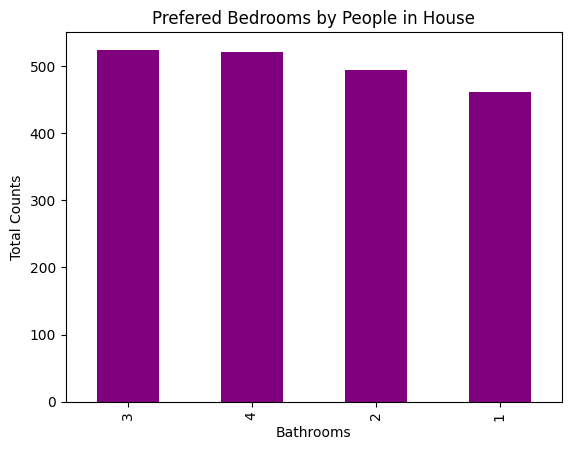

In [11]:
data['Bathrooms'].value_counts().plot(kind='bar',color='purple',title='Prefered Bedrooms by People in House',ylabel='Total Counts')

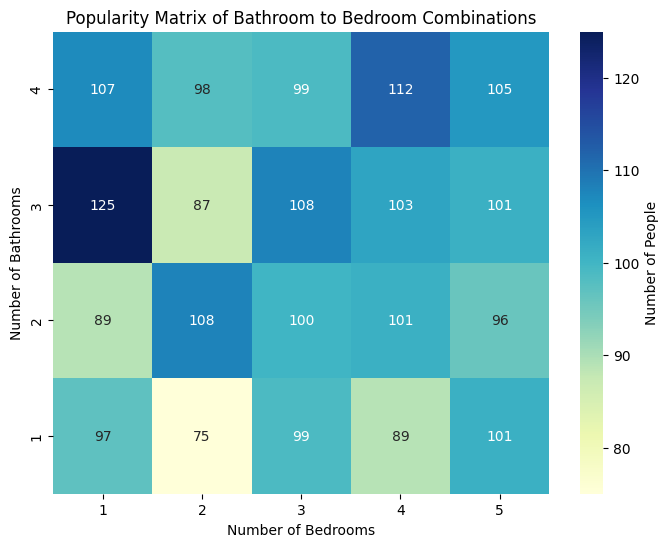

In [12]:
preference_matrix = data.groupby(["Bathrooms", "Bedrooms"]).size().unstack(fill_value=0)

plt.figure(figsize=(8, 6))
sns.heatmap(preference_matrix, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': 'Number of People'})

plt.title("Popularity Matrix of Bathroom to Bedroom Combinations")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Number of Bathrooms")
plt.gca().invert_yaxis()  # Keeps lower counts at the bottom
plt.show()


<Axes: title={'center': 'Prefer Floor by the People'}, xlabel='Floors', ylabel='Frequency Count'>

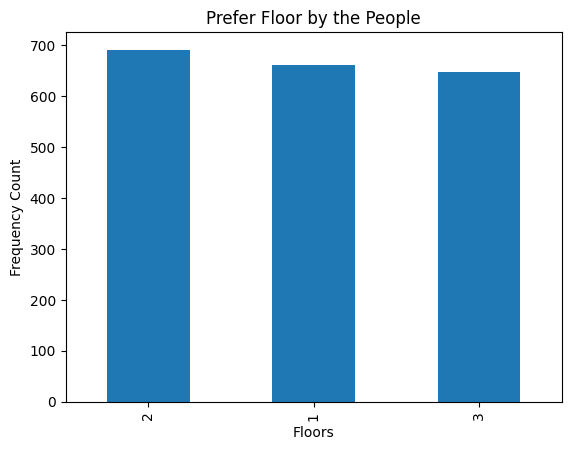

In [13]:
data['Floors'].value_counts().plot(kind='bar',title='Prefer Floor by the People',ylabel='Frequency Count')

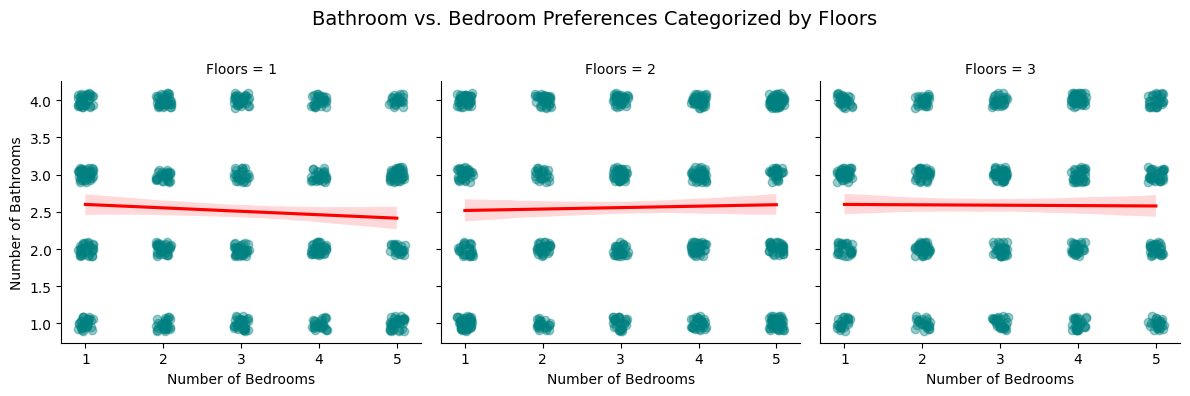

In [14]:
# Create separate subplots side-by-side based on the 'floors' column
g = sns.FacetGrid(data, col="Floors", height=4, aspect=1, col_wrap=3)

# Map a regression plot (scatter + trendline) onto each subplot
g.map(sns.regplot, "Bedrooms", "Bathrooms", 
      x_jitter=0.1, y_jitter=0.1, 
      scatter_kws={'alpha':0.4, 'color':'teal'}, 
      line_kws={'color':'red'})

g.set_axis_labels("Number of Bedrooms", "Number of Bathrooms")
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle("Bathroom vs. Bedroom Preferences Categorized by Floors", fontsize=14)

plt.show()


In [15]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


<Axes: title={'center': 'Ten Highest Number of House Build in Year'}, xlabel='YearBuilt', ylabel='Frequency'>

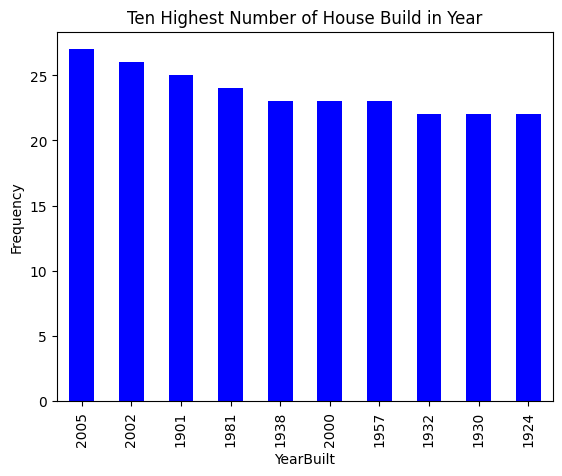

In [16]:
data['YearBuilt'].value_counts().head(10).plot(kind='bar',color='blue',title='Ten Highest Number of House Build in Year',ylabel='Frequency')

<Axes: title={'center': 'Location prefer to build house'}, xlabel='Location', ylabel='Frequency Count'>

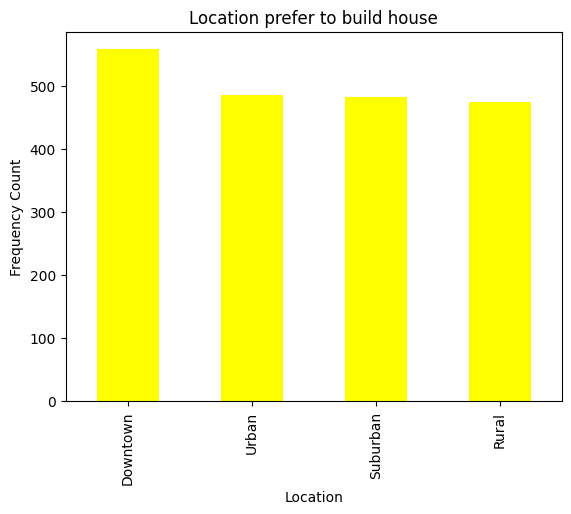

In [17]:
data['Location'].value_counts().plot(kind='bar',color='yellow',title='Location prefer to build house',ylabel='Frequency Count')

In [18]:
import numpy as np

num_cols = ["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt"]
print(df[num_cols + ["Price"]].corr()["Price"].sort_values())

Bathrooms   -0.015737
Bedrooms    -0.003471
Area         0.001542
YearBuilt    0.004845
Floors       0.055890
Price        1.000000
Name: Price, dtype: float64


In [19]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [20]:
X = data.iloc[0:,1:-1]
y = data.iloc[0:,-1:]
y

,Price
0,149919
1,424998
2,266746
3,244020
4,636056
...,...
1995,295620
1996,580929
1997,476925
1998,161119


In [21]:
#data['Condition'].value_counts()

In [22]:
#from sklearn.preprocessing import OrdinalEncoder
#from sklearn.preprocessing import LabelEncoder

#other_data_left = data.iloc[0:, :6].values   # Columns 0 to 5
#other_data_right = data.iloc[0:, 9:].values  # Columns 8 onwards

#ordinal_data = data.iloc[0:, 6:8].values
#label_data = data.iloc[0:,8].values
#oe = OrdinalEncoder(categories=[['Downtown','Urban','Suburban','Rural'],['Excellent','Good','Fair','Poor']])
#le = LabelEncoder()
#label_encoded = le.fit_transform(label_data).reshape(-1,1)
#encoded_cols = oe.fit_transform(ordinal_data)

#final_array = np.hstack((other_data_left,label_encoded,encoded_cols,other_data_right))

#data = pd.DataFrame(final_array, columns=data.columns)"""


In [23]:
#X = data.iloc[0:,1:9]
#y = data.iloc[0:,-1:]



In [24]:
#from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [25]:
#from sklearn.linear_model import LinearRegression
#reg = LinearRegression()

In [26]:
#reg.fit(X_train,y_train)

In [27]:
#y_pred = reg.predict(X_test)


In [28]:
#from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming 'y_test' contains actual prices and 'y_pred' contains your model's predictions
#mae = mean_absolute_error(y_test, y_pred)
#mse = mean_squared_error(y_test, y_pred)
#rmse = np.sqrt(mse)
#r2 = r2_score(y_test, y_pred)

#print("--- Model Evaluation Metrics ---")
#print(f"Mean Absolute Error (MAE):     {mae:,.2f}")
#print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
#print(f"R-squared (R2) Score:          {r2:.4f}")


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

#df = pd.read_csv("House Price Prediction Dataset.csv")
#X = df.drop(columns=["Id", "Price"])   # drop the identifier and target
#y = df["Price"]                         # 1D target

#pre = ColumnTransformer([
    #("cond", OrdinalEncoder(categories=[["Poor","Fair","Good","Excellent"]]), ["Condition"]),
    #("loc",  OneHotEncoder(handle_unknown="ignore"), ["Location"]),
    #("gar",  OneHotEncoder(drop="if_binary"), ["Garage"]),
#], remainder="passthrough")            # numeric cols pass through untouched

#X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

#tree = Pipeline([("pre", pre), ("model", DecisionTreeRegressor(max_depth=5, random_state=42))])
#tree.fit(X_tr, y_tr)
#print("Tree test R²:", tree.score(X_te, y_te))
#print("Tree CV R²:", cross_val_score(tree, X_tr, y_tr, cv=5, scoring="r2").mean())"""

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

pre = ColumnTransformer(
    transformers=[
        ("cond", OrdinalEncoder(categories=[["Poor", "Fair", "Good", "Excellent"]]), ["Condition"]),
        ("loc",  OneHotEncoder(handle_unknown="ignore"), ["Location"]),
        ("gar",  OneHotEncoder(drop="if_binary"), ["Garage"]),
    ],
    remainder="passthrough",
)

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
reg = Pipeline([("pre",pre), ("model", LinearRegression())])
reg.fit(X_train,y_train)
print("Reg test R^2 :", reg.score(X_test,y_test))
print("Reg CV R^2 :", cross_val_score(reg,X_train,y_train, cv= 5, scoring='r2').mean())



Reg test R^2 : -0.008143099974382118
Reg CV R^2 : -0.006721797699597287


In [32]:
import numpy as np

num_cols = ["Area", "Bedrooms", "Bathrooms", "Floors", "YearBuilt"]
print(df[num_cols + ["Price"]].corr()["Price"].sort_values())

Bathrooms   -0.015737
Bedrooms    -0.003471
Area         0.001542
YearBuilt    0.004845
Floors       0.055890
Price        1.000000
Name: Price, dtype: float64


In [33]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_val_score

pre = ColumnTransformer([
    ("cond", OrdinalEncoder(categories=[["Poor","Fair","Good","Excellent"]]), ["Condition"]),
    ("loc",  OneHotEncoder(handle_unknown="ignore"), ["Location"]),
    ("gar",  OneHotEncoder(drop="if_binary"), ["Garage"]),
    ("num",  StandardScaler(), ["Area","Bedrooms","Bathrooms","Floors","YearBuilt"]),
])  # explicit num list replaces remainder so everything is scaled

reg = Pipeline([("pre", pre), ("model", LinearRegression())])
reg.fit(X_train, y_train)

dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)

cv = cross_val_score(reg, X_train, y_train, cv=5, scoring="r2")
print(f"Baseline (mean) R²: {dummy.score(X_test, y_test):.4f}")
print(f"Reg test R²:        {reg.score(X_test, y_test):.4f}")
print(f"Reg CV R²:          {cv.mean():.4f} ± {cv.std():.4f}")

Baseline (mean) R²: -0.0007
Reg test R²:        -0.0081
Reg CV R²:          -0.0067 ± 0.0068
